In [2]:
import random
import math
import pickle
import numpy as np
import torch
import sklearn.datasets
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import clear_output
from torch.utils.tensorboard import SummaryWriter
import os
import sklearn
import torch.nn as nn
import torch.optim.lr_scheduler as lr_scheduler

from torch.distributions import MixtureSameFamily, Categorical, MultivariateNormal, Independent, Normal


#import torchvision.transforms as transforms
#import torchvision.datasets as datasets
#import torchvision.transforms as transforms

#import sys
#sys.path.insert(0, '..')

In [3]:
class Sampler:
    def __init__(
        self, device='cuda',
    ):
        self.device = device
    
    def sample(self, size=5):
        pass

In [4]:
class TensorSampler(Sampler):
    def __init__(self, tensor, device='cuda'):
        super(TensorSampler, self).__init__(device)
        self.tensor = torch.clone(tensor).to(device)
        
    def sample(self, size=5):
        assert size <= self.tensor.shape[0]
        
        ind = torch.tensor(np.random.choice(np.arange(self.tensor.shape[0]), size=size, replace=False), device=self.device)
        return torch.clone(self.tensor[ind]).detach().to(self.device)


In [5]:
class EOTConfig:
    def __init__(self,
                 eps: float = 0.1,
                 batch_size: int = 2048,
                 device: str ="cpu",
                 K: int = 32,
                 epoch: int = 100,
                 theta_step_every: int = 2,
                 reg_phi: float = 0,
                 reg_theta: float = 0,
                 reg_diff: float = 0,
                 oneD_grid = torch.linspace(-1.0, 1.0, 100),
                 lmc_steps: int = 100,
                 lmc_step_size: float = 0.003,
                 samples_per_hist: int = 100000,
                 seed: int = 42,
                 lbfgs_training: bool = False,
                 sampling_sigma: float = 1.0,
                 grad_clip = 100000.0,
                 max_diff_exp_clip=100,
                 ema_momentum=0.999
        ):
        # Устройство
        self.device = device

        # Параметры EOT
        self.eps = eps                      # ε - параметр энтропийной регуляризации
        #self.sqrt_eps = math.sqrt(self.eps) # √ε для гауссовской свёртки
        self.sampling_sigma = sampling_sigma

        # Параметры обучения
        self.batch_size = batch_size              # Размер батча
        self.K = K                         # Число MC-сэмплов для E_z[exp(...)]
        self.epoch = epoch                 # Общее число итераций
        self.theta_step_every = theta_step_every           # Чередование: 1 шага phi, 1 шаг theta
        self.reg_phi = reg_phi
        self.reg_theta = reg_theta
        self.reg_diff = reg_diff
        self.lbfgs_training=lbfgs_training
        self.score_clip = 100000.0
        self.grad_clip = grad_clip
        self.max_diff_exp_clip = max_diff_exp_clip

        self.oneD_grid = oneD_grid
        self.grid_x, self.grid_y = torch.meshgrid(self.oneD_grid, self.oneD_grid)#, indexing='ij')

        # Параметры Langevin MCMC
        self.lmc_steps = lmc_steps                # Число шагов Langevin динамики
        self.lmc_step_size = lmc_step_size          # Размер шага η в ULA


        # метрики
        self.samples_per_hist = samples_per_hist

        # EMA параметр
        self.ema_momentum = ema_momentum

        # Seed для воспроизводимости
        self.seed = seed

In [6]:
class MLP(nn.Module):
    """
    Многослойный перцептрон для аппроксимации двойственных потенциалов.
    
    Архитектура:
        Input(2D) → Linear(128) → SiLU → Linear(128) → SiLU → Linear(1) → Output(scalar)
    """
    def __init__(self, din=2, hidden=128, dout=1, multiplier=1.0):
        super().__init__()
        self.multiplier = multiplier
        self.net = nn.Sequential(
            nn.Linear(din, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, dout),
        )
    
    def forward(self, x):
        #norms = torch.norm(x, p=2, dim=1, keepdim=True).to(trainer.config.device) ** 2
        #input_tensor = torch.cat([x, norms], dim=1)
        #input_tensor = torch.cat([x, x ** 2], dim=1)
        return self.multiplier * self.net(x)


In [7]:
DIM = 512
assert DIM > 1

INPUT_DATA = "MAN" # MAN, WOMAN, ADULT, CHILDREN
TARGET_DATA = "WOMAN" # MAN, WOMAN, ADULT, CHILDREN

OUTPUT_SEED = 0xBADBEEF
BATCH_SIZE = 128
EPSILON = 0.1
D_LR = 1e-3 # 1e-3 for eps 0.1
D_GRADIENT_MAX_NORM = float("inf")
N_POTENTIALS = 10
SAMPLING_BATCH_SIZE = 128
INIT_BY_SAMPLES = True
IS_DIAGONAL = True

MAX_STEPS = 10000
CONTINUE = -1

In [8]:
# To download data use

train_size = 60000
test_size = 10000

latents = np.load("../data/latents.npy")
gender = np.load("../data/gender.npy")
age = np.load("../data/age.npy")
test_inp_images = np.load("../data/test_images.npy")

train_latents, test_latents = latents[:train_size], latents[train_size:]
train_gender, test_gender = gender[:train_size], gender[train_size:]
train_age, test_age = age[:train_size], age[train_size:]

if INPUT_DATA == "MAN":
    x_inds_train = np.arange(train_size)[(train_gender == "male").reshape(-1)]
    x_inds_test = np.arange(test_size)[(test_gender == "male").reshape(-1)]
elif INPUT_DATA == "WOMAN":
    x_inds_train = np.arange(train_size)[(train_gender == "female").reshape(-1)]
    x_inds_test = np.arange(test_size)[(test_gender == "female").reshape(-1)]
elif INPUT_DATA == "ADULT":
    x_inds_train = np.arange(train_size)[
        (train_age >= 18).reshape(-1)*(train_age != -1).reshape(-1)
    ]
    x_inds_test = np.arange(test_size)[
        (test_age >= 18).reshape(-1)*(test_age != -1).reshape(-1)
    ]
elif INPUT_DATA == "CHILDREN":
    x_inds_train = np.arange(train_size)[
        (train_age < 18).reshape(-1)*(train_age != -1).reshape(-1)
    ]
    x_inds_test = np.arange(test_size)[
        (test_age < 18).reshape(-1)*(test_age != -1).reshape(-1)
    ]
x_data_train = train_latents[x_inds_train]
x_data_test = test_latents[x_inds_test]

if TARGET_DATA == "MAN":
    y_inds_train = np.arange(train_size)[(train_gender == "male").reshape(-1)]
    y_inds_test = np.arange(test_size)[(test_gender == "male").reshape(-1)]
elif TARGET_DATA == "WOMAN":
    y_inds_train = np.arange(train_size)[(train_gender == "female").reshape(-1)]
    y_inds_test = np.arange(test_size)[(test_gender == "female").reshape(-1)]
elif TARGET_DATA == "ADULT":
    y_inds_train = np.arange(train_size)[
        (train_age >= 18).reshape(-1)*(train_age != -1).reshape(-1)
    ]
    y_inds_test = np.arange(test_size)[
        (test_age >= 18).reshape(-1)*(test_age != -1).reshape(-1)
    ]
elif TARGET_DATA == "CHILDREN":
    y_inds_train = np.arange(train_size)[
        (train_age < 18).reshape(-1)*(train_age != -1).reshape(-1)
    ]
    y_inds_test = np.arange(test_size)[
        (test_age < 18).reshape(-1)*(test_age != -1).reshape(-1)
    ]
y_data_train = train_latents[y_inds_train]
y_data_test = test_latents[y_inds_test]

X_train = torch.tensor(x_data_train)
Y_train = torch.tensor(y_data_train)

X_test = torch.tensor(x_data_test)
Y_test = torch.tensor(y_data_test)

X_sampler = TensorSampler(X_train, device="cpu")
Y_sampler = TensorSampler(Y_train, device="cpu")

In [9]:
#from eot.utils import compute_histogram_2d, compute_histogram_norms
class EOTTrainer:
    """
    Тренер для Energy-Guided Entropic Optimal Transport.

    Решает задачу энтропийного оптимального транспорта между двумя
    распределениями P(x) и Q(y) через двойственную формулировку.
    """

    def __init__(self, config, source_sampler, target_sampler, opt_theta, opt_phi, scheduler, model_theta, model_phi, name):
        """
        Args:
            config: объект EOTConfig с гиперпараметрами
            source_sampler: сэмплер для P(x)
            target_sampler: сэмплер для Q(y)
        """
        
        self.writer = SummaryWriter(f'runs3/{name}')
        self.experiment_name = name

        self.config = config
        self.source_sampler = source_sampler
        self.target_sampler = target_sampler

        self.config.dim_source = self.source_sampler.sample(1).shape.numel()
        self.config.dim_target = self.target_sampler.sample(1).shape.numel()

        # Инициализация моделей
        self.f_theta = model_theta #MLP(multiplier=1.0).to(config.device)
        self.f_phi = model_phi #MLP(multiplier=1.0).to(config.device)
        import copy
        self.f_theta_ema = copy.deepcopy(self.f_theta).eval()
        for p in self.f_theta_ema.parameters(): p.requires_grad_(False)

        # Оптимизаторы
        self.opt_theta = opt_theta
        self.opt_phi = opt_phi
        
        self.bad_z_x = []
        #self.opt_both = torch.optim.AdamW(
        #    list(self.f_theta.parameters()) + list(self.f_phi.parameters()),
        #    lr=1e-4,
        #    weight_decay=0
        #)

        # История обучения
        self.loss_history = []
        self.metric_history = []
        self.loss_phi_hist = []
        self.blowout_logger_theta = []
        self.blowout_logger_phi = []
        self.max_delta = []
        self.mean_delta = []

        # история метрик
        self.L1 = []
        self.L2 = []
        self.Linf = []
        self.logger = {"f_theta" : {"min": [], "max" : [], "mean" : [], "median" : []}, "f_phi" : {"min": [], "max" : [], "mean" : [], "median" : []}}

        self.min_f_theta = []
        self.max_f_theta = []
        self.mean_f_theta = []
        self.median_f_theta = []
        self.min_phi = []
        self.max_phi = []
        self.mean_phi = []
        self.median_phi = []

        self.f_theta_on_grid = []
        self.phi_on_grid = []

        self.current_step = 0
        self.current_step_phi = 0
        self.current_step_theta = 0

    def ema_update(self, model, ema):
        m = self.config.ema_momentum
        with torch.no_grad():
            for p, pe in zip(model.parameters(), ema.parameters()):
                pe.mul_(m).add_(p, alpha=1-m)

        
    def compute_loss(self, x, y):
        cfg = self.config

        # Сэмплируем z и веса для подсчёта матожидания
        broad_shape = list(x.shape)
        broad_shape.insert(1, cfg.K)
        z = torch.randn(size=broad_shape, device=cfg.device) * self.config.sampling_sigma
        
        weight_z = 1.0
        if (cfg.sampling_sigma != 1.0):
            weight_z = ((cfg.sampling_sigma) ** (cfg.dim_source)) * torch.exp(0.5 * (1 / (cfg.sampling_sigma) ** 2 - 1.0) * (z ** 2).sum(dim=tuple(range(2, len(broad_shape)))))        

        x_noisy = x[:, None, :] - math.sqrt(cfg.eps(self.current_step)) * z

        if (self.train_phi):
            fphi_x = self.f_phi(x)
            regularization_phi = cfg.reg_phi(self.current_step_phi) * (fphi_x ** 2).mean()
        else:
            with torch.no_grad():
                fphi_x = self.f_phi(x)
                regularization_phi = cfg.reg_phi(self.current_step_phi) * (fphi_x ** 2).mean()
            
        if torch.isnan(fphi_x).any():
            raise Exception("fphi_x has nan")
            
        if (self.train_theta):
            ftheta_xnoisy = self.f_theta(x_noisy.reshape(-1, *x_noisy.shape[2:])).view(cfg.batch_size, cfg.K) / cfg.eps(self.current_step)
            ftheta_in_zero = self.f_theta(torch.zeros(dimension).unsqueeze(0).to(self.config.device))
            ftheta_y = self.f_theta(y)
            regularization_theta = cfg.reg_theta(self.current_step_theta) * ((ftheta_y ** 2).mean() + (ftheta_xnoisy ** 2).mean())
        else:
            with torch.no_grad():
                ftheta_xnoisy = self.f_theta(x_noisy.reshape(-1, *x_noisy.shape[2:])).view(cfg.batch_size, cfg.K) / cfg.eps(self.current_step)
                ftheta_in_zero = self.f_theta(torch.zeros(dimension).unsqueeze(0).to(self.config.device))
                ftheta_y = self.f_theta(y)
                regularization_theta = cfg.reg_theta(self.current_step_theta) * ((ftheta_y ** 2).mean() + (ftheta_xnoisy ** 2).mean())

        diff_in_exp = ftheta_xnoisy - fphi_x
        self.max_delta.append(diff_in_exp.detach().cpu().max().item())
        diff_in_exp_truncated = torch.clamp(diff_in_exp, min=-10, max=10)
        valid_mask = (diff_in_exp >= -10) & (diff_in_exp <= 10)
        #if (valid_mask.sum() < 100):
        #    raise Exception("Sorry") 
        exp_term = torch.exp(diff_in_exp_truncated.to(torch.float64))
        exp_term = exp_term * valid_mask * weight_z
        #exp_term = torch.where(diff_in_exp_truncated > 20, diff_in_exp_truncated.pow(7), torch.exp(diff_in_exp_truncated.to(torch.float64))) * weight_z

                
        if torch.isnan(exp_term).any():
            raise Exception("exp_term has nan")
        if torch.isnan(ftheta_y).any():
            raise Exception("ftheta_y has nan")
        if torch.isnan(ftheta_xnoisy).any():
            raise Exception("ftheta_xnoisy has nan")

        
        global_max_idx = torch.argmax(diff_in_exp.detach())  
        global_batch_idx = global_max_idx // cfg.K
        global_k_idx = global_max_idx % cfg.K       # Индекс K
        global_max_z = z[global_batch_idx, global_k_idx]  # [dim_source]  
        global_max_x = x[global_batch_idx]
        self.bad_z_x.append((global_max_z.detach().cpu(), global_max_x.detach().cpu(), ((global_max_x - math.sqrt(cfg.eps(self.current_step)) * global_max_z) ** 2).sum().detach().cpu().item()))

        ftheta_y_mean = ftheta_y.mean()
        fphi_x_mean = fphi_x.mean()
        Loss_theor = (fphi_x_mean + exp_term.mean()) * cfg.eps(self.current_step) - ftheta_y_mean
        Loss_reg =  cfg.reg_zero_point(self.current_step_theta) * (ftheta_in_zero ** 2 ) + \
                     regularization_theta + regularization_phi
        L_main = Loss_theor + Loss_reg 

        
        #self.writer.add_scalar('Loss/regularization_phi', regularization_phi.item(), self.current_step)
        #self.writer.add_scalar('Loss/fphi_x', fphi_x_mean.item(), self.current_step)

        self.writer.add_scalar('Loss/Full_optimization_loss', L_main.item(), self.current_step)
        self.writer.add_scalar('Loss/Reg_loss', Loss_reg.item(), self.current_step)
        self.writer.add_scalar('Loss/Theor_loss', Loss_theor.item(), self.current_step)

        self.writer.add_scalar('Loss/ftheta_y', ftheta_y_mean.item(), self.current_step)
        self.writer.add_scalar('Loss/fphi_x', fphi_x_mean.item(), self.current_step)
        self.writer.add_scalars('Loss/exp_term_theta', {
            'min': exp_term.min().item(),
            'mean': exp_term.mean().item(),
            'median': exp_term.median().item(),
        }, self.current_step)   
        self.writer.add_scalar('Loss/exp_term_max_theta', exp_term.max().item(), self.current_step)
        self.writer.add_scalar('Loss/regularization_theta', regularization_phi.item(), self.current_step)
        self.writer.add_scalar('Loss/regularization_phi', regularization_phi.item(), self.current_step)
        self.writer.add_scalar('Loss/ftheta_in_zero', ftheta_in_zero.item(), self.current_step)
        
        self.writer.add_scalar('Parameters/reg_zero_point', cfg.reg_zero_point(self.current_step_theta), self.current_step)
        self.writer.add_scalar('Parameters/reg_theta', cfg.reg_theta(self.current_step_theta), self.current_step)
        self.writer.add_scalar('Parameters/reg_phi', cfg.reg_phi(self.current_step_phi), self.current_step)
        
        loss_dict = {'step': self.current_step, 
                     'Full_optimization_loss' : L_main.item(),
                     'Reg_loss': Loss_reg.item(),
                     'Theor_loss': Loss_theor.item(),
                     'ftheta_y': ftheta_y_mean.item(),
                     'fphi_x': fphi_x_mean.item(),
                     'exp_term_theta_min' : exp_term.min().item(),
                     'exp_term_theta_mean' : exp_term.mean().item(),
                     'exp_term_theta_median' : exp_term.median().item(),
                     'exp_term_theta_max': exp_term.max().item(),
                     'Loss/regularization_theta': regularization_phi.item(),
                     'Loss/regularization_phi': regularization_phi.item(),
                     'Loss/ftheta_in_zero': ftheta_in_zero.item(),
        }
        self.loss_history.append(loss_dict)
        
        return L_main

    
    def train_step(self):
                
        if (self.strategy_alternating_optimization):
            for i in range(self.config.theta_step_every - 1, -1, -1):
                x = self.source_sampler.sample(self.config.batch_size).to(self.config.device)
                y = self.target_sampler.sample(self.config.batch_size).to(self.config.device)
                if (i % self.config.theta_step_every != 0):
                    self.train_theta = False
                    self.train_phi = True
                    loss = self.compute_loss(x, y)
                    self.opt_both.zero_grad(set_to_none=True)
                    loss.backward()
                    self.logg_grad()
                    torch.nn.utils.clip_grad_norm_(self.f_phi.parameters(), max_norm=self.config.grad_clip)
                    self.opt_both.step()
                    self.current_step += 1
                    self.current_step_phi += 1
                else:
                    self.train_theta = True
                    self.train_phi = False
                    loss = self.compute_loss(x, y)
                    self.opt_both.zero_grad(set_to_none=True)
                    loss.backward()
                    self.logg_grad()
                    torch.nn.utils.clip_grad_norm_(self.f_theta.parameters(), max_norm=self.config.grad_clip)
                    self.opt_both.step()
                    self.ema_update(self.f_theta, self.f_theta_ema)
                    self.current_step += 1
                    self.current_step_theta += 1
        else:
            x = self.source_sampler.sample(self.config.batch_size).to(self.config.device)
            y = self.target_sampler.sample(self.config.batch_size).to(self.config.device)
            self.train_theta = True
            self.train_phi = True
            loss = self.compute_loss(x, y)
            self.opt_both.zero_grad(set_to_none=True)
            loss.backward()
            self.logg_grad()
            torch.nn.utils.clip_grad_norm_(self.f_theta.parameters(), max_norm=self.config.grad_clip)
            torch.nn.utils.clip_grad_norm_(self.f_phi.parameters(), max_norm=self.config.grad_clip)
            self.opt_both.step()
            self.ema_update(self.f_theta, self.f_theta_ema)
            self.current_step += 1
            self.current_step_theta += 1
            self.current_step_phi += 1



    def train(self, viz_callback=None):
        print(f"Starting training name = {self.experiment_name}")
        #print(f"ε={self.config.eps(self.current_step)}")
        print("-" * 60)

        while True:
            L_main = self.train_step()
            viz_callback(self)
            if (self.current_step >= self.config.epoch):
                break

        print("Training complete!")
        return 0
    
    def logg_grad(self):
        for p in self.f_phi.parameters():
            if p.grad is not None and torch.isnan(p.grad).any():
                raise Exception("grad f_phi has nan")
        for p in self.f_theta.parameters():
            if p.grad is not None and torch.isnan(p.grad).any():
                raise Exception("grad f_theta has nan")

        total_norm = 0.0
        for p in self.f_theta.parameters():
            if p.grad is not None:
                total_norm += p.grad.norm(2).item() ** 2
        total_norm = total_norm ** 0.5
        self.writer.add_scalar('gradients/global_norm_theta', total_norm, self.current_step)
        
        total_norm = 0.0
        for p in self.f_phi.parameters():
            if p.grad is not None:
                total_norm += p.grad.norm(2).item() ** 2
        total_norm = total_norm ** 0.5
        self.writer.add_scalar('gradients/global_norm_phi', total_norm, self.current_step)
        
        for name, param in self.f_theta.named_parameters():
            if param.grad is not None:
                grad_norm = param.grad.norm(2).item()
                self.writer.add_scalar(f'gradients_theta/layer_norm/{name}', grad_norm, self.current_step)
        for name, param in self.f_phi.named_parameters():
            if param.grad is not None:
                grad_norm = param.grad.norm(2).item()
                self.writer.add_scalar(f'gradients_phi/layer_norm/{name}', grad_norm, self.current_step)


    def calculate_magnitude(self, model, name ="f_theta"):
        grid_positions = torch.stack([self.config.grid_x, self.config.grid_y], dim=-1)
        function_on_grid = model(grid_positions.to(self.config.device)).detach().cpu()
        self.logger[name]["max"].append(function_on_grid.max().item())
        self.logger[name]["min"].append(function_on_grid.min().item())
        self.logger[name]["mean"].append(function_on_grid.mean().item())
        self.logger[name]["median"].append(function_on_grid.median().item())
        #self.f_theta_on_grid.append(function_on_grid)

        
    def compute_gauss_metric(self, batch_size=128):
        eps = self.config.eps(self.current_step)
        dimension = self.source_sampler.dim
        with torch.no_grad():
            const_in_zero = self.f_theta(torch.zeros(dimension).unsqueeze(0).to(self.config.device)).item()
        z = torch.randn((batch_size, dimension))

        with torch.no_grad():
            prediction_potential = (self.f_theta(z.to(self.config.device)).detach().cpu() - const_in_zero)

        norms = torch.norm(z, p=2, dim=1, keepdim=True)
        theor_potential = (norms ** 2) * (-math.sqrt(eps * eps + 4) - eps + 2) / 4
        diff = ((theor_potential - prediction_potential) ** 2)
        gaussian_metric_mean = diff.mean()
        gaussian_metric_max = diff.max()
        gaussian_metric_median = diff.median()
        gaussian_metric_min = diff.min()
        
        self.writer.add_scalars('Loss/gaussian_metric', {
            'min': gaussian_metric_min.item(),
            'mean': gaussian_metric_mean.item(),
            'median': gaussian_metric_median.item(),
            #'max': gaussian_metric_max.item(),
        }, self.current_step)
        
        
        # ===== Гиперпараметры =====
        NUM_DIRECTIONS = 100
        ALPHA = (-math.sqrt(eps * eps + 4) - eps + 2) / 4  # коэффициент в теоретической функции alpha * ||x||^2
        SCALES = sorted([1.0, 4.0, 16.0, 64.0, 128.0, 256.0, 512.0, 1024.0, 2048.0, dimension * (1 + eps), dimension * (1 + eps) / 2, dimension * (1 + eps) * 2])

        # ===== Генерируем и нормализуем направления =====
        directions = torch.randn((NUM_DIRECTIONS, dimension))
        directions = directions / torch.norm(directions, p=2, dim=1, keepdim=True)
        # directions shape: (NUM_DIRECTIONS, dimension)

        # ===== Основной цикл по масштабам =====
        results = {scale: [] for scale in SCALES}  # для каждого масштаба храним ошибки по всем направлениям

        for scale in SCALES:
            scaled_vectors = directions * scale  # (NUM_DIRECTIONS, dimension)

            # Применяем модель
            model_outputs = self.f_theta(scaled_vectors.to(self.config.device)).detach().cpu()
            model_outputs = model_outputs.squeeze()  # (NUM_DIRECTIONS,)

            # Теоретические значения: alpha * ||x||^2 = alpha * scale^2
            theoretical = ALPHA * (scale ** 2) * torch.ones(NUM_DIRECTIONS)

            # Ошибка (абсолютная разница)
            errors = torch.abs(model_outputs - theoretical)
            results[scale] = errors.numpy()

        # ===== Вычисляем метрики для каждого масштаба =====
        metrics_data = []
        max_errors_by_scale = {}
        for scale in SCALES:
            errors = results[scale]
            metrics_data.append({
                'scale': scale,
                'max': np.max(errors),
                'mean': np.mean(errors),
                'median': np.median(errors),
                'min': np.min(errors),
                'std': np.std(errors)
            })
            max_errors_by_scale[str(scale)] = np.max(errors)
        
        self.writer.add_scalars('max_error_by_scale', max_errors_by_scale, self.current_step)
        self.metric_history.append([max_errors_by_scale, self.current_step])
        
        return gaussian_metric_min.item(), gaussian_metric_mean.item(), gaussian_metric_median.item(), metrics_data
        

    def compute_metrics(self, points=100000):
        y_tgt = self.target_sampler.sample(points).cpu().numpy()
        y_hat = self.sample_marginal(points).cpu().numpy()
        hist1 = compute_histogram_2d(
            y_tgt,
            xlim=(self.config.oneD_grid[0], self.config.oneD_grid[-1]),
            ylim=(self.config.oneD_grid[0], self.config.oneD_grid[-1]),
            n_bins_x=len(self.config.oneD_grid),
            n_bins_y=len(self.config.oneD_grid),
            normalize=True
        )
        hist2 = compute_histogram_2d(
            y_hat,
            xlim=(self.config.oneD_grid[0], self.config.oneD_grid[-1]),
            ylim=(self.config.oneD_grid[0], self.config.oneD_grid[-1]),
            n_bins_x=len(self.config.oneD_grid),
            n_bins_y=len(self.config.oneD_grid),
            normalize=True
        )
        norms = compute_histogram_norms(hist1, hist2)
        
        self.writer.add_scalar('Visualization/Histogram_matric_L1', norms["L1"], self.current_step)
        self.writer.add_scalar('Metrics/Histogram_matric_L1', norms["L1"], self.current_step)
        self.writer.add_scalar('Metrics/Histogram_matric_L2', norms["L2"], self.current_step)
        self.writer.add_scalar('Metrics/Histogram_matric_Linf', norms["Linf"], self.current_step)

    def score_y_given_x(self, y, x):
        """
        Вычисление score function для условного плана π(y|x).

        Score: ∇_y log π(y|x) = (1/ε)[∇_y f_theta(y) - (y-x)]

        Args:
            y: позиции (batch_size, 2), требует градиента
            x: условие (batch_size, 2)
        Returns:
            score ∇_y log π(y|x)
        """
        y = y.detach().requires_grad_(True)

        # Градиент f_theta по y
        ft = self.f_theta_ema(y).sum()
        (gy,) = torch.autograd.grad(ft, y, retain_graph=False, create_graph=False)

        # Score = [∇f - (y-x)]/ε
        sc = (gy - (y - x)) / self.config.eps(self.current_step)

        return torch.clamp(sc, -self.config.score_clip, self.config.score_clip)

    def sample_pi_given_x(self, x):
        """
        Сэмплирование из π(y|x) через Langevin MCMC.

        Args:
            x: условие, тензор (batch_size, dim)
            n: число сэмплов
        Returns:
            тензор (n, dim) с сэмплами
        """
        cfg = self.config
        y = x + 0.0 * math.sqrt(cfg.eps(self.current_step)) * torch.randn(x.shape[0], x.shape[1], device=cfg.device)

        for _ in range(cfg.lmc_steps):
            y = y.detach()
            sc = self.score_y_given_x(y, x)

            with torch.no_grad():
                y = y + cfg.lmc_step_size * sc + \
                    math.sqrt(2 * cfg.lmc_step_size) * torch.randn_like(y)

        return y.detach()

    def sample_marginal(self, n_x=500):
        """
        Сэмплирование из маргинального распределения через EOT план.

        Процедура:
        1. x ~ P(x)
        2. y ~ π(y|x) через Langevin
        3. Результат: y ~ Q(y)

        Args:
            n_x: число точек
        Returns:
            тензор (n_x, 2)
        """
        cfg = self.config
        xs = self.source_sampler.sample(n_x)
        y = xs

        for _ in range(cfg.lmc_steps):
            y = y.detach()
            sc = self.score_y_given_x(y, xs)

            with torch.no_grad():
                y = y + cfg.lmc_step_size * sc + \
                    math.sqrt(2 * cfg.lmc_step_size) * torch.randn_like(y)

        return y.detach()

    def heatmap_logger_phi(self, grid_resolution=200):
        cfg = self.config
        device = cfg.device

        # Создаем сетку для heatmap
        x_grid = np.linspace(-2.5, 2.5, grid_resolution)
        y_grid = np.linspace(-2.5, 2.5, grid_resolution)
        X, Y = np.meshgrid(x_grid, y_grid)

        # Вычисляем f_theta на сетке
        grid_points = torch.tensor(np.stack([X.ravel(), Y.ravel()], axis=1), 
                                  dtype=torch.float32, device=device)

        with torch.no_grad():
            f_theta_values = self.f_phi(grid_points).cpu().numpy()

        f_theta_grid = f_theta_values.reshape(X.shape)
        
        self.writer.add_scalars('Visualization/f_phi_stats', {
            'max': f_theta_grid.max().item(),
            'min': f_theta_grid.min().item(),
            'mean': f_theta_grid.mean().item(),
        }, self.current_step)   


        # Создаем график
        plt.figure(figsize=(12, 10))

        # Heatmap f_theta
        im = plt.imshow(f_theta_grid, 
                       extent=[-2.5, 2.5, -2.5, 2.5], 
                       origin='lower', 
                       cmap='viridis', 
                       alpha=0.8,
                       aspect='equal')

        # Добавляем contour lines для лучшей читаемости
        contour = plt.contour(X, Y, f_theta_grid, levels=10, colors='black', alpha=0.5, linewidths=0.5)
        plt.clabel(contour, inline=True, fontsize=8, fmt='%1.1f')

        # Настройки графика
        plt.xlim(-2.5, 2.5)
        plt.ylim(-2.5, 2.5)
        plt.xlabel('X координата')
        plt.ylabel('Y координата')
        plt.grid(True, alpha=0.3)

        # Цветовая шкала
        cbar = plt.colorbar(im, label='Значение f_phi')

        # Убедимся, что соотношение сторон правильное
        plt.gca().set_aspect('equal')

        self.writer.add_figure('Visualization/f_phi_heatmap', plt.gcf(), self.current_step)
    
    
    def heatmap_logger(self, grid_resolution=200):
        cfg = self.config
        device = cfg.device

        # Создаем сетку для heatmap
        x_grid = np.linspace(-2.5, 2.5, grid_resolution)
        y_grid = np.linspace(-2.5, 2.5, grid_resolution)
        X, Y = np.meshgrid(x_grid, y_grid)

        # Вычисляем f_theta на сетке
        grid_points = torch.tensor(np.stack([X.ravel(), Y.ravel()], axis=1), 
                                  dtype=torch.float32, device=device)

        with torch.no_grad():
            f_theta_values = self.f_theta(grid_points).cpu().numpy()

        f_theta_grid = f_theta_values.reshape(X.shape)
        
        self.writer.add_scalars('Visualization/f_theta_stats', {
            'max': f_theta_grid.max().item(),
            'min': f_theta_grid.min().item(),
            'mean': f_theta_grid.mean().item(),
        }, self.current_step)   


        # Создаем график
        plt.figure(figsize=(12, 10))

        # Heatmap f_theta
        im = plt.imshow(f_theta_grid, 
                       extent=[-2.5, 2.5, -2.5, 2.5], 
                       origin='lower', 
                       cmap='viridis', 
                       alpha=0.8,
                       aspect='equal')

        # Добавляем contour lines для лучшей читаемости
        contour = plt.contour(X, Y, f_theta_grid, levels=10, colors='black', alpha=0.5, linewidths=0.5)
        plt.clabel(contour, inline=True, fontsize=8, fmt='%1.1f')

        # Настройки графика
        plt.xlim(-2.5, 2.5)
        plt.ylim(-2.5, 2.5)
        plt.xlabel('X координата')
        plt.ylabel('Y координата')
        plt.grid(True, alpha=0.3)

        # Цветовая шкала
        cbar = plt.colorbar(im, label='Значение f_theta')

        # Убедимся, что соотношение сторон правильное
        plt.gca().set_aspect('equal')

        self.writer.add_figure('Visualization/f_theta_heatmap', plt.gcf(), self.current_step)
        return f_theta_grid
        
    def sampler_logger(self, grid_resolution=200, points=5000):
        cfg = self.config
        device = cfg.device
        
        y_tgt = self.target_sampler.sample(points).cpu().numpy()
        y_hat = self.sample_marginal(points).cpu().numpy()

        # Создаем сетку для heatmap
        x_grid = np.linspace(-2.5, 2.5, grid_resolution)
        y_grid = np.linspace(-2.5, 2.5, grid_resolution)

        # Создаем график
        plt.figure(figsize=(12, 10))
        
        plt.scatter(y_tgt[:, 0], y_tgt[:, 1], s=7, alpha=0.25, label="target Q(y)")
        plt.scatter(y_hat[:, 0], y_hat[:, 1], s=7, alpha=0.25, label="generated")

        # Настройки графика
        plt.xlim(-2.5, 2.5)
        plt.ylim(-2.5, 2.5)
        plt.xlabel('X координата')
        plt.legend()
        plt.ylabel('Y координата')
        plt.grid(True, alpha=0.3)

        # Убедимся, что соотношение сторон правильное
        plt.gca().set_aspect('equal')

        self.writer.add_figure('Visualization/samples', plt.gcf(), self.current_step)

    def image_Visualization(self):
        torch.manual_seed(OUTPUT_SEED); np.random.seed(OUTPUT_SEED)
        number_of_samples = 1
        inds_to_map = np.random.choice(np.arange((x_inds_test < 300).sum()), size=20, replace=False)
        mapped_all = []
        latent_to_map = torch.tensor(test_latents[x_inds_test[inds_to_map]])
        inp_images = test_inp_images[x_inds_test[inds_to_map]]
        mapped = self.sample_pi_given_x(latent_to_map.to(self.config.device)).to("cuda")
        
        with torch.no_grad():
            # Декодирование оригинальных тестовых латентов
            decoded_orig = decode(model, latent_to_map.to(self.config.device))
            decoded_orig = ((decoded_orig * 0.5 + 0.5) * 255).type(torch.long).clamp(0, 255).cpu().type(torch.uint8).permute(0, 2, 3, 1).numpy()
            
            # Декодирование сгенерированных латентов
            decoded_img = decode(model, mapped)
            decoded_img = ((decoded_img * 0.5 + 0.5) * 255).type(torch.long).clamp(0, 255).cpu().type(torch.uint8).permute(0, 2, 3, 1).numpy()
        
        # Три строки: входные изображения, оригинальные реконструкции, сгенерированные
        num_images = 20
        fig, axes = plt.subplots(3, num_images, figsize=(num_images*2, 6), dpi=100)
        
        for i in range(num_images):
            # Верхняя строка - входные изображения
            axes[0, i].imshow(inp_images[i])
            axes[0, i].set_title(f'Input {i}', fontsize=8)
            axes[0, i].get_xaxis().set_visible(False)
            axes[0, i].set_yticks([])
            
            # Средняя строка - декодированные оригинальные латенты
            axes[1, i].imshow(decoded_orig[i])
            axes[1, i].set_title(f'Orig {i}', fontsize=8)
            axes[1, i].get_xaxis().set_visible(False)
            axes[1, i].set_yticks([])
            
            # Нижняя строка - декодированные сгенерированные латенты
            axes[2, i].imshow(decoded_img[i])
            axes[2, i].set_title(f'Gen {i}', fontsize=8)
            axes[2, i].get_xaxis().set_visible(False)
            axes[2, i].set_yticks([])
        
        fig.tight_layout(pad=0.05)
        # Сохранение в файл
        os.makedirs(self.experiment_name, exist_ok=True)
        plt.savefig(f'{self.experiment_name}/recon_step_{self.current_step}.png', bbox_inches='tight', dpi=100)
        self.writer.add_figure('Reconstructions', fig, global_step=self.current_step)
        plt.close(fig)


    def save_checkpoint(self, filename):
        checkpoint = {
            'f_theta_state_dict': self.f_theta_ema.state_dict(),
            'f_phi_state_dict': self.f_phi.state_dict(),
            'epoch': self.current_step,
            'eps': self.config.eps(self.current_step),
        }
        torch.save(checkpoint, filename)


In [10]:
def compute_loss(self, x, y):
    cfg = self.config

    # Сэмплируем z и веса для подсчёта матожидания
    broad_shape = list(x.shape)
    broad_shape.insert(1, cfg.K)
    #broad_shape[0] *= 2
    z = torch.randn(size=broad_shape, device=cfg.device) * self.config.sampling_sigma(self.current_step)
    
    log_weight_z = 0.0
    log_weight_z = 0.5 * (1 / (cfg.sampling_sigma(self.current_step)) ** 2 - 1.0) * (z ** 2).sum(dim=tuple(range(2, len(broad_shape))))
    log_weight_z -= cfg.dim_source * np.log(cfg.sampling_sigma(self.current_step))
        #weight_z = ((cfg.sampling_sigma) ** (cfg.dim_source)) * torch.exp(0.5 * (1 / (cfg.sampling_sigma) ** 2 - 1.0) * (z ** 2).sum(dim=tuple(range(2, len(broad_shape)))))        

    x_noisy = x[:, None, :] - math.sqrt(cfg.eps(self.current_step)) * z

    if (self.train_phi):
        fphi_x = self.f_phi(x)
        #fphi_y = self.f_phi(y)
        #regularization_phi = cfg.reg_phi(self.current_step_phi) * (fphi_x ** 2).mean()
    else:
        with torch.no_grad():
            fphi_x = self.f_phi(x)
            #fphi_y = self.f_phi(y)
            #regularization_phi = cfg.reg_phi(self.current_step_phi) * (fphi_x ** 2).mean()
        
    if torch.isnan(fphi_x).any():
        raise Exception("fphi_x has nan")
        
    if (self.train_theta):
        ftheta_xnoisy = self.f_theta(x_noisy.reshape(-1, *x_noisy.shape[2:])).view(cfg.batch_size, cfg.K) / cfg.eps(self.current_step)
        ftheta_in_zero = self.f_theta(torch.zeros(dimension).unsqueeze(0).to(self.config.device))
        ftheta_y = self.f_theta(y)
        #regularization_theta = cfg.reg_theta(self.current_step_theta) * ((ftheta_y ** 2).mean() + (ftheta_xnoisy ** 2).mean())
    else:
        with torch.no_grad():
            ftheta_xnoisy = self.f_theta(x_noisy.reshape(-1, *x_noisy.shape[2:])).view(cfg.batch_size, cfg.K) / cfg.eps(self.current_step)
            #ftheta_in_zero = self.f_theta(torch.zeros(dimension).unsqueeze(0).to(self.config.device))
            ftheta_y = self.f_theta(y)
            #regularization_theta = cfg.reg_theta(self.current_step_theta) * ((ftheta_y ** 2).mean() + (ftheta_xnoisy ** 2).mean())

    diff_in_exp = ftheta_xnoisy - fphi_x + log_weight_z
    if torch.isnan(diff_in_exp).any():
        raise Exception("diff_in_exp has nan")

    self.max_delta.append(diff_in_exp.detach().cpu().max().item())
    diff_in_exp_truncated = torch.clamp(diff_in_exp, min=None, max=self.config.max_diff_exp_clip)
    #valid_mask = (diff_in_exp <= self.config.max_diff_exp_clip)
    #if (valid_mask.sum() < 100):
    #    raise Exception("Sorry") 
    exp_term = torch.exp(diff_in_exp_truncated.to(torch.float64)) #* valid_mask
    #exp_term = exp_term #* weight_z # valid_mask *
    #return exp_term

    #exp_terms = torch.exp(diff_in_exp.to(torch.float64))  
    #valid_mask = torch.isfinite(exp_terms) & (exp_terms < torch.exp(torch.tensor([self.config.max_diff_exp_clip])).to("cuda"))
    #exp_term = exp_terms[valid_mask].mean() if valid_mask.sum() > 0 else 0.0

    if torch.isnan(exp_term).any():
        num_nans = torch.isnan(exp_term).sum().item()
        print(f"Количество NaN: {num_nans}")
    
        # Находим позиции NaN
        nan_positions = torch.where(torch.isnan(exp_term))
        nan_index = (nan_positions[0][0].item(), nan_positions[1][0].item())  # или nan_positions[0][0].item(), nan_positions[1][0].item()
        value = diff_in_exp_truncated[nan_index]
        print("value = ", value) 
        print("Позиции NaN (индексы):", nan_positions)
        raise Exception("exp_term has nan")
    if torch.isnan(ftheta_y).any():
        raise Exception("ftheta_y has nan")
    if torch.isnan(ftheta_xnoisy).any():
        raise Exception("ftheta_xnoisy has nan")

    
    global_max_idx = torch.argmax(diff_in_exp.detach())  
    global_batch_idx = global_max_idx // cfg.K
    global_k_idx = global_max_idx % cfg.K       # Индекс K
    global_max_z = z[global_batch_idx, global_k_idx]  # [dim_source]  
    global_max_x = x[global_batch_idx]
    self.bad_z_x.append((global_max_z.detach().cpu(), global_max_x.detach().cpu(), global_max_x - math.sqrt(cfg.eps(self.current_step)) * global_max_z))

    ftheta_y_mean = ftheta_y.mean()
    fphi_x_mean = fphi_x.mean()
    Loss_theor = (fphi_x_mean + exp_term.mean()) * cfg.eps(self.current_step) - ftheta_y_mean
    #Loss_reg =  cfg.reg_zero_point(self.current_step_theta) * (ftheta_in_zero ** 2 ) + \
    #             regularization_theta + regularization_phi
    L_main = Loss_theor# + Loss_reg 
    
    #self.writer.add_scalar('Loss/regularization_phi', regularization_phi.item(), self.current_step)
    #self.writer.add_scalar('Loss/fphi_x', fphi_x_mean.item(), self.current_step)

    self.writer.add_scalar('Loss/Full_optimization_loss', L_main.item(), self.current_step)
    #self.writer.add_scalar('Loss/Reg_loss', Loss_reg.item(), self.current_step)
    self.writer.add_scalar('Loss/Theor_loss', Loss_theor.item(), self.current_step)

    self.writer.add_scalar('Loss/ftheta_y', ftheta_y_mean.item(), self.current_step)
    self.writer.add_scalar('Loss/fphi_x', fphi_x_mean.item(), self.current_step)
    self.writer.add_scalars('Loss/exp_term_theta', {
        'min': exp_term.min().item(),
        'mean': exp_term.mean().item(),
        'median': exp_term.median().item(),
    }, self.current_step)   
    self.writer.add_scalar('Loss/exp_term_max_theta', exp_term.max().item(), self.current_step)
    #self.writer.add_scalar('Loss/regularization_theta', regularization_phi.item(), self.current_step)
    #self.writer.add_scalar('Loss/regularization_phi', regularization_phi.item(), self.current_step)
    self.writer.add_scalar('Loss/ftheta_in_zero', ftheta_in_zero.item(), self.current_step)
    
    #self.writer.add_scalar('Parameters/reg_zero_point', cfg.reg_zero_point(self.current_step_theta), self.current_step)
    #self.writer.add_scalar('Parameters/reg_theta', cfg.reg_theta(self.current_step_theta), self.current_step)
    #self.writer.add_scalar('Parameters/reg_phi', cfg.reg_phi(self.current_step_phi), self.current_step)
    self.writer.add_scalar('Parameters/log_weight_z_min', log_weight_z.min().item(), self.current_step)
    self.writer.add_scalar('Parameters/log_weight_z_max', log_weight_z.max().item(), self.current_step)
    self.writer.add_scalar('Parameters/log_weight_z_median', log_weight_z.median().item(), self.current_step)
    self.writer.add_scalar('Parameters/log_weight_z_mean', log_weight_z.mean().item(), self.current_step)

    
    loss_dict = {'step': self.current_step, 
                 'Full_optimization_loss' : L_main.item(),
                 #'Reg_loss': Loss_reg.item(),
                 'Theor_loss': Loss_theor.item(),
                 'ftheta_y': ftheta_y_mean.item(),
                 'fphi_x': fphi_x_mean.item(),
                 'exp_term_theta_min' : exp_term.min().item(),
                 'exp_term_theta_mean' : exp_term.mean().item(),
                 'exp_term_theta_median' : exp_term.median().item(),
                 'exp_term_theta_max': exp_term.max().item(),
                 #'Loss/regularization_theta': regularization_theta.item(),
                 #'Loss/regularization_phi': regularization_phi.item(),
                 #'Loss/ftheta_in_zero': ftheta_in_zero.item(),
    }
    self.loss_history.append(loss_dict)
    
    return L_main
EOTTrainer.compute_loss = compute_loss

In [11]:
def visualize_training(trainer):
    
    trainer.writer.add_scalars('Params', {
        'K': trainer.config.K,
        'eps': trainer.config.eps(trainer.current_step),
        'batch_size': trainer.config.batch_size,
        'reg_phi' : trainer.config.reg_phi(trainer.current_step_phi),
        'reg_theta' : trainer.config.reg_theta((trainer.current_step_theta)),
        'theta_step_every' : trainer.config.theta_step_every,
        'lr' : trainer.opt_both.param_groups[0]['lr'],
        'beta1' : trainer.opt_both.param_groups[0]['betas'][0],
        'beta2' : trainer.opt_both.param_groups[0]['betas'][1],
        'lmc_steps' : trainer.config.lmc_steps,
        'lmc_step_size' : trainer.config.lmc_step_size,
        'sampling_sigma' : trainer.config.sampling_sigma(trainer.current_step)
    }, trainer.current_step)
    
    trainer.writer.add_scalar('Visualization/max_diff_in_exp', trainer.max_delta[-1], trainer.current_step)
    
    
    #if (trainer.current_step % 100 == 0):
    #    trainer.compute_gauss_metric(batch_size=1024)
    """
    if (trainer.current_step % 500 == 0):
        for name, param in trainer.f_theta.named_parameters():
            trainer.writer.add_histogram(f'Weights_theta/{name}', param, trainer.current_step)
            if param.grad is not None:
                trainer.writer.add_histogram(f'Weight_theta_Gradients/{name}', param.grad, trainer.current_step)
        for name, param in trainer.f_phi.named_parameters():
            trainer.writer.add_histogram(f'Weights_phi/{name}', param, trainer.current_step)
            if param.grad is not None:
                trainer.writer.add_histogram(f'Weight_phi_Gradients/{name}', param.grad, trainer.current_step)
    """
    if (trainer.current_step % 250 == 0):
        with torch.no_grad():
            f_X_phi = trainer.f_phi(X_train.to("cuda")).cpu().reshape(-1)
            f_X_train = trainer.f_theta(X_train.to("cuda")).cpu().reshape(-1)
            f_Y_train = trainer.f_theta(Y_train.to("cuda")).cpu().reshape(-1)
        
        data = torch.cat([f_X_train.unsqueeze(0), f_X_phi.unsqueeze(0)], dim=0)
        sorted_indices = torch.argsort(data[0])
        sorted_tensor = data[:, sorted_indices]

        # Отрисовка на созданной figure
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.plot(sorted_tensor[0], label="f_theta")
        ax.plot(sorted_tensor[1], label="phi")
        ax.plot(sorted_tensor[0] - sorted_tensor[1], label="diff")
        ax.legend()
        ax.set_xlabel('Index')
        ax.set_ylabel('Value')
        ax.set_title('Phi/Theta Distribution')
        ax.grid(True, alpha=0.3)
        trainer.writer.add_figure('phi/theta distribution', fig, global_step=trainer.current_step)
        plt.close(fig)

    if (trainer.current_step % 500 == 0):
        os.makedirs(f"../checkpoints/{trainer.experiment_name}", exist_ok=True)
        trainer.save_checkpoint(f"../checkpoints/{trainer.experiment_name}/{trainer.current_step}.pth")
    if (trainer.current_step % 2000 == 0):
        trainer.image_Visualization()
    #    trainer.heatmap_logger()
    #    trainer.heatmap_logger_phi()
    #    trainer.sampler_logger(points=10000)
    #    trainer.compute_metrics()

In [12]:
config = EOTConfig(
     eps = 0.1,
     batch_size = 2,
     device = torch.device("cuda" if torch.cuda.is_available() else "cpu"),
     K = 32,
     epoch = 100,
     theta_step_every = 2,
     reg_phi = 0.01,
     reg_theta = 0.0,
     reg_diff = 0.0,
     oneD_grid = torch.linspace(-3.0, 3.0, 100),
     lmc_steps = 100,
     lmc_step_size = 0.003,
     samples_per_hist = 100000,
     seed = 42,
     lbfgs_training=False,
     ema_momentum=0.999
)

/trinity/home/roman.dyachenko/miniconda3/envs/nlp_env/lib/python3.10/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [13]:
import os, sys
sys.path.append("..")
sys.path.append("../ALAE")

from alae_ffhq_inference import load_model, encode, decode

model = load_model("../ALAE/configs/ffhq.yaml", training_artifacts_dir="../ALAE/training_artifacts/ffhq/").cuda()

In [25]:
dimension = DIM
trainer = EOTTrainer(
    config=config,
    source_sampler=X_sampler,#Mix8GaussiansSampler(dim=2, device=config.device),#ColoredMNIST2Sampler(device=config.device, alpha=1.0),
    target_sampler=Y_sampler,#StandardNormalSampler(dim=dimension),#ColoredMNIST3Sampler(device=config.device, alpha=1.0),
    model_theta=MLP(din=dimension, hidden=256).to(config.device), #AttentionMLP(din=512).to(config.device), #MLP(din=dimension, hidden=520).to(config.device), #VanillaNet(n_c=3, n_f=32).to(config.device),
    model_phi=MLP(din=dimension, hidden=256).to(config.device), #AttentionMLP(din=512).to(config.device),#MLP(din=dimension, hidden=520).to(config.device), #VanillaNet(n_c=3, n_f=32).to(config.device),
    opt_theta=None,
    opt_phi=None,
    scheduler=None,
    name = f"test247_M2W_EPS=1.0"
)

trainer.opt_theta = torch.optim.AdamW(
            trainer.f_theta.parameters(),
            lr=3e-4,
            weight_decay=0
        )

trainer.opt_phi = torch.optim.AdamW(
            trainer.f_phi.parameters(),
            lr=3e-4,
            weight_decay=0
        )
trainer.opt_both = torch.optim.AdamW(
            list(trainer.f_phi.parameters()) + list(trainer.f_theta.parameters()),
            lr=3e-4,
            weight_decay=0,
            betas = (0.8, 0.9)
        )
#trainer.scheduler = lr_scheduler.CosineAnnealingLR(trainer.opt_both, T_max=100000, eta_min=1e-6)

In [28]:
trainer.config.epoch=100000
trainer.config.batch_size = 256
trainer.config.K = 256

trainer.config.eps = lambda step: 1.0

#trainer.config.eps = lambda step, eps_start=1.0, eps_end=0.1, total_steps=trainer.config.epoch, warmup_steps=3000: \
#    eps_start if step < warmup_steps else \
#    eps_start * (eps_end / eps_start) ** ((1 - np.cos(np.pi * (step - warmup_steps) / (total_steps - warmup_steps))) / 2)
trainer.config.lmc_step_size = 0.001
trainer.config.lmc_steps = 1000

trainer.config.ema_momentum=0.999

trainer.config.grad_clip = 1000000000
trainer.config.max_diff_exp_clip = 40 #30

#"""
reg_schedulers = {
    'phi': lambda epoch: 0.0, #1e-3 #lambda epoch: a * (b / a) ** (epoch / trainer.config.epoch),
    'theta': lambda epoch: 0.0, #lambda epoch: a * (b / a) ** (epoch / trainer.config.epoch),
    'zero_point': lambda e: 0.0
}
"""

a = 1.0
b = 1e-3

reg_schedulers = {
    'phi': lambda epoch: a * (b / a) ** (epoch / trainer.config.epoch),
    'theta': lambda epoch: a * (b / a) ** (epoch / trainer.config.epoch),
    'zero_point': lambda e: 0.0
}
"""

trainer.config.reg_phi = reg_schedulers["phi"]
trainer.config.reg_theta = reg_schedulers["theta"]
trainer.config.reg_zero_point = reg_schedulers["zero_point"]

trainer.strategy_alternating_optimization = False
trainer.config.theta_step_every=2

sigma_start = 1.0
sigma_end = 1.0

trainer.config.sampling_sigma = lambda epoch: sigma_start * (sigma_end / sigma_start) ** (epoch / trainer.config.epoch)

trainer.opt_both.param_groups[0]['lr'] = 1e-4
trainer.opt_both.param_groups[0]['betas'] = (0.7, 0.8)
trainer.opt_both.param_groups[0]['weight_decay'] = 1e-4

In [29]:
trainer.train(viz_callback=lambda t: visualize_training(t))

Starting training name = test247_M2W_EPS=1.0
------------------------------------------------------------
Training complete!


0

# Sampling

In [66]:
import einops

In [60]:
#from eot.utils import compute_histogram_2d, compute_histogram_norms
class EOTT_sampler:
    """
    Тренер для Energy-Guided Entropic Optimal Transport.

    Решает задачу энтропийного оптимального транспорта между двумя
    распределениями P(x) и Q(y) через двойственную формулировку.
    """

    def __init__(self, model_theta, model_phi, eps, lmc_step_size, lmc_steps):
        """
        Args:
            config: объект EOTConfig с гиперпараметрами
            source_sampler: сэмплер для P(x)
            target_sampler: сэмплер для Q(y)
        """
        # Инициализация моделей
        self.f_theta = model_theta #MLP(multiplier=1.0).to(config.device)
        self.f_phi = model_phi #MLP(multiplier=1.0).to(config.device)
        self.eps = eps
        self.score_clip = 1000000
        self.lmc_step_size = lmc_step_size
        self.lmc_steps = lmc_steps
        
    
    def score_y_given_x(self, y, x):
        y = y.detach().requires_grad_(True)

        ft = self.f_theta(y).sum()
        (gy,) = torch.autograd.grad(ft, y, retain_graph=False, create_graph=False)

        # Score = [∇f - (y-x)]/ε
        sc = (gy - (y - x)) / self.eps

        return torch.clamp(sc, -self.score_clip, self.score_clip)

    def sample_pi_given_x(self, x, n=200):
        y = x.unsqueeze(1) + 0.0 * (self.eps ** 0.5) * torch.randn(x.shape[0], n, x.shape[1], device="cuda")
        for _ in range(self.lmc_steps):
            y = y.detach()
            sc = self.score_y_given_x(y, x.unsqueeze(1))
            with torch.no_grad():
                y = y + self.lmc_step_size * sc + math.sqrt(2*self.lmc_step_size) * torch.randn_like(y)
        return y.detach()

    def sample_marginal(self, n_x=500):
        xs = self.source_sampler.sample(n_x)
        y = xs

        for _ in range(self.lmc_steps):
            y = y.detach()
            sc = self.score_y_given_x(y, xs)

            with torch.no_grad():
                y = y + self.lmc_step_size * sc + \
                    math.sqrt(2 * self.lmc_step_size) * torch.randn_like(y)

        return y.detach()
    
        

In [61]:
torch.manual_seed(OUTPUT_SEED); np.random.seed(OUTPUT_SEED)
task = "M2W"
exp_name = f"test239_{task}_EPS=1.0"

epoch = 8000

lmc_step_size = 0.01
lmc_steps = 100

N = 12
repeat = 3

In [62]:
checkpoint = torch.load(f'../checkpoints/{exp_name}/{epoch}.pth', weights_only=False)
model_theta=MLP(din=512, hidden=256).to("cuda")
model_phi=MLP(din=512, hidden=256).to("cuda")

model_theta.load_state_dict(checkpoint['f_theta_state_dict'])
model_phi.load_state_dict(checkpoint['f_phi_state_dict'])
sampler = EOTT_sampler(
    model_theta=model_theta,
    model_phi=model_phi,
    eps = checkpoint["eps"],
    lmc_step_size=lmc_step_size,
    lmc_steps=lmc_steps,
)

In [64]:
inds_to_map = np.random.choice(np.arange((x_inds_test < 300).sum()), size=N, replace=False)
mapped_all = []
latent_to_map = torch.tensor(test_latents[x_inds_test[inds_to_map]])
mapped = sampler.sample_pi_given_x(latent_to_map.to("cuda"), n=repeat).to("cuda")

ref_plus_gen = torch.cat([latent_to_map.to("cuda").unsqueeze(1), mapped], dim=1)
with torch.no_grad():
    decoded_img = decode(model, ref_plus_gen.reshape(-1, 512))
    decoded_img = ((decoded_img * 0.5 + 0.5) * 255).type(torch.long).clamp(0, 255).cpu().type(torch.uint8).permute(0, 2, 3, 1).numpy()
    decoded_img = decoded_img.reshape(N, repeat + 1, 1024, 1024, 3)

def show_image_grid(images, figsize=(15, 6)):
    plt.close('all')
    %matplotlib inline
    """Отображает grid с einops."""
    if isinstance(images, torch.Tensor):
        images = images.cpu().numpy()
    
    # (cols, rows, H, W, C) -> (rows*H, cols*W, C)
    grid = einops.rearrange(images, 'cols rows h w c -> (rows h) (cols w) c')
    
    # Нормализуем в [0, 1]
    if grid.max() > 1.0:
        grid = grid / 255.0
    
    plt.figure(figsize=figsize)
    plt.imshow(grid)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# show_image_grid(images, figsize=(15, 6))

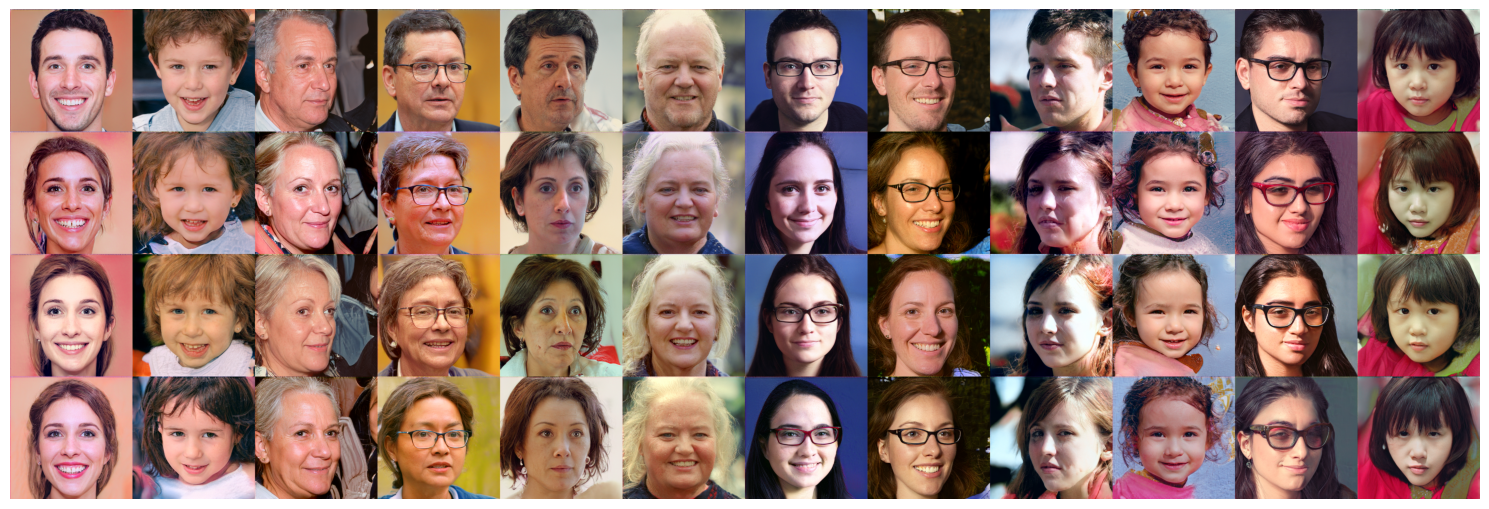

In [67]:
show_image_grid(decoded_img)

In [18]:
N = 50000
dim = 512
z = torch.randn((dim, N)) * (0.1 ** 0.5)
norm_z = torch.norm(z, dim=0)
plt.plot(norm_z.sort().values)
norm_z.mean()

tensor(7.1521)

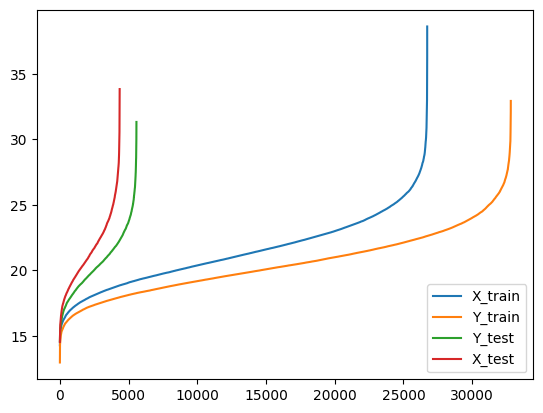

In [218]:
X_train_norm = torch.norm(X_train, dim = 1)
Y_train_norm = torch.norm(Y_train, dim = 1)
Y_test_norm = torch.norm(Y_test, dim = 1)
X_test_norm = torch.norm(X_test, dim = 1)


plt.plot(X_train_norm.sort().values, label = "X_train")
plt.plot(Y_train_norm.sort().values, label = "Y_train")
plt.plot(Y_test_norm.sort().values, label = "Y_test")
plt.plot(X_test_norm.sort().values, label = "X_test")

plt.legend()

In [192]:
bad_z = torch.cat([i[0].unsqueeze(0) for i in trainer.bad_z_x])
bad_x = torch.cat([i[1].unsqueeze(0) for i in trainer.bad_z_x])
diff = bad_x - bad_z 

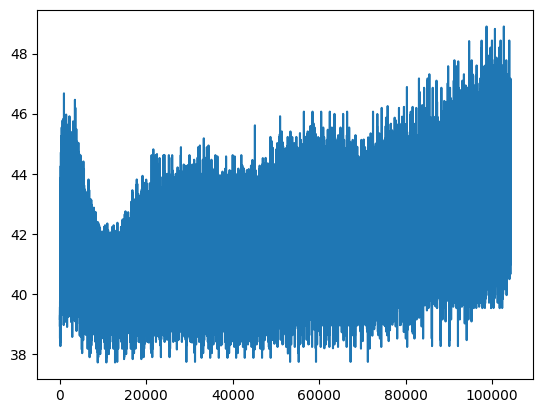

In [224]:
plt.close('all')
%matplotlib inline

#plt.plot(torch.norm(bad_x, dim = 1))
plt.plot(torch.norm(bad_z, dim = 1))
#plt.plot(torch.norm(diff, dim = 1))

In [228]:
torch.norm(diff, dim = 1).min(), torch.norm(diff, dim = 1).max()

(tensor(41.3981), tensor(61.0969))

In [39]:
trainer.config.lmc_step_size = 0.01
trainer.config.lmc_steps = 100#200

trainer.current_step += 1
trainer.image_Visualization()

In [171]:
from torch.utils.data import TensorDataset, DataLoader

with torch.no_grad():
    f_X_phi = trainer.f_phi(X_train.to("cuda")).cpu().reshape(-1)
    f_X_train = trainer.f_theta(X_train.to("cuda")).cpu().reshape(-1)
    f_Y_train = trainer.f_theta(Y_train.to("cuda")).cpu().reshape(-1)


data = torch.cat([f_X_train.unsqueeze(0), f_X_phi.unsqueeze(0)], dim=0)
sorted_indices = torch.argsort(data[0])
sorted_tensor = data[:, sorted_indices]
plt.plot(sorted_tensor[0], label = "f_theta")
plt.plot(sorted_tensor[1], label = "phi")
plt.plot(sorted_tensor[0] - sorted_tensor[1], label = "diff")
plt.legend()

In [287]:
f_X_train.reshape(-1).sort().indices

tensor([21877, 15990, 24646,  ...,  3866,  3004, 24169])

In [183]:
x_inds_train[f_X_train.reshape(-1).sort().indices][-10:]

array([24609, 58023,  9169,  7210,  6041, 49007, 44683, 26421,  1440,
       32135])

In [184]:
x_inds_train[f_X_train.reshape(-1).sort().indices][:10]

array([57811, 54431, 46456, 25154, 22014, 42773, 49304, 59110, 30169,
       41456])

In [185]:
x_inds_train[f_X_phi.reshape(-1).sort().indices][-10:]

array([57996, 49007, 17561,  1440, 26421,  6041, 24609, 44683, 58023,
       32135])

In [186]:
y_inds_train[f_Y_train.reshape(-1).sort().indices][-10:]

array([31250, 39505, 42044,  7868, 59584, 37602, 58891, 26514, 15186,
       58350])

In [187]:
y_inds_train[f_Y_train.reshape(-1).sort().indices][:10]

array([51632, 41067, 22544, 39467,  3387, 19942, 53358, 42807, 46047,
       15601])

In [25]:
f_X_train

tensor([-32.5213, 145.2940, 143.2562,  ...,   3.0760,  90.7866, -20.8047])

In [26]:
f_X_phi

tensor([-515.6155, -583.2593, -531.4786,  ..., -574.6447, -566.0414,
        -606.7120])

In [31]:
data = torch.cat([f_X_train.unsqueeze(0), f_X_phi.unsqueeze(0)], dim=0)

In [42]:
data

tensor([[ -32.5213,  145.2940,  143.2562,  ...,    3.0760,   90.7866,
          -20.8047],
        [-515.6155, -583.2593, -531.4786,  ..., -574.6447, -566.0414,
         -606.7120]])

In [36]:
data[0]

tensor([-32.5213, 145.2940, 143.2562,  ...,   3.0760,  90.7866, -20.8047])

In [37]:
sorted_indices = torch.argsort(data[0])
sorted_tensor = data[:, sorted_indices]

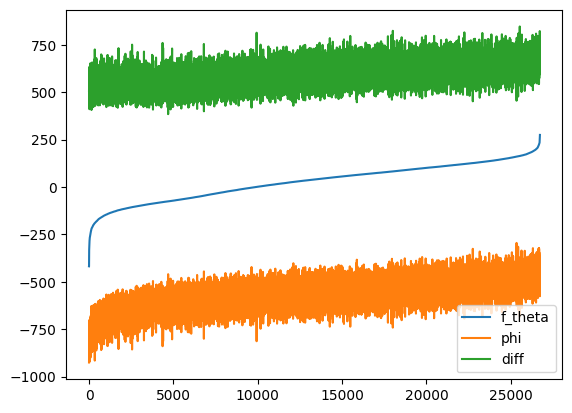

In [49]:
plt.plot(sorted_tensor[0], label = "f_theta")
plt.plot(sorted_tensor[1], label = "phi")
plt.plot(sorted_tensor[0] - sorted_tensor[1], label = "diff")
plt.legend()

In [39]:
sorted_tensor

tensor([[-418.2134, -417.8374, -367.2497,  ...,  267.0902,  268.9501,
          274.6446],
        [-925.1583, -910.2725, -859.6982,  ..., -377.4957, -451.2704,
         -397.1170]])

In [43]:
data[0, 24768], data[1, 24768]

(tensor(-417.8374), tensor(-910.2725))

In [38]:
sorted_indices

tensor([24646, 24768, 18557,  ..., 14392,  2736, 25869])

(tensor(-563.9961), tensor(26.2212))

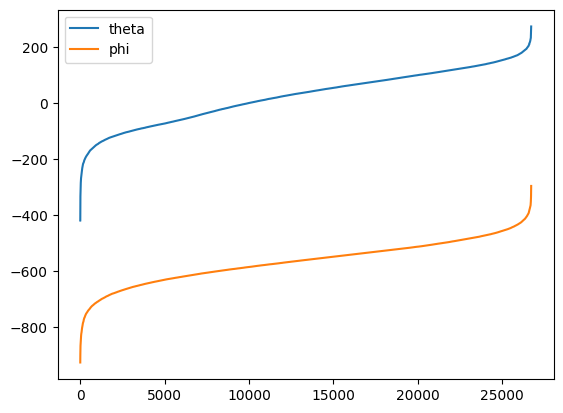

In [24]:
plt.close('all')
%matplotlib inline
plt.plot(f_X_train.reshape(-1).sort().values, label = "theta")
plt.plot(f_X_phi.reshape(-1).sort().values, label = "phi")
plt.legend()
f_X_phi.mean(), f_X_train.mean()

In [51]:
f_X_phi.reshape(-1).sort().values

tensor([-13323.4238, -12393.7920, -11620.2998,  ..., 147274.5312,
        151133.6406, 154365.9688])

In [52]:
f_X_train.reshape(-1).sort().values

tensor([-2340.5488, -2323.5854, -2226.4246,  ..., 15437.2422, 15756.9395,
        15930.4434])

In [40]:
f_X_phi.mean()

tensor(23042.2344)

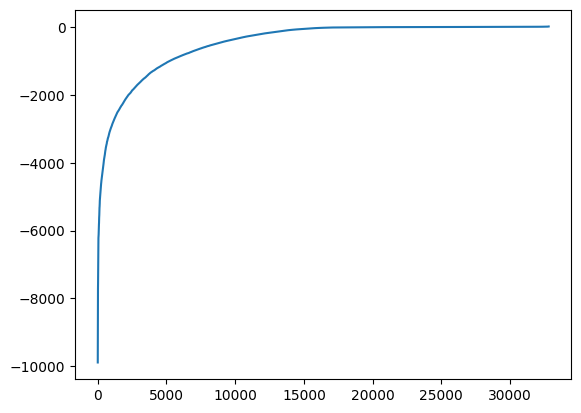

tensor(-465.4043)

In [57]:
plt.close('all')
%matplotlib inline
plt.plot(f_Y_train.reshape(-1).sort().values)
plt.show()
f_Y_train.mean()

In [52]:
import torch

def pairwise_euclidean_distance(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """
    Быстрое вычисление попарных евклидовых расстояний между X и Y.
    
    Args:
        x: Tensor shape (n, 512)
        y: Tensor shape (m, 512)
    
    Returns:
        Tensor shape (n, m) с евклидовыми расстояниями
    """
    # Развертываем в 2D если нужно
    x_flat = x.view(-1, 512)
    y_flat = y.view(-1, 512)
    
    # Используем формулу: ||x - y||² = ||x||² + ||y||² - 2⟨x,y⟩
    x_norm = (x_flat ** 2).sum(dim=1, keepdim=True)  # (n, 1)
    y_norm = (y_flat ** 2).sum(dim=1, keepdim=True)  # (m, 1)
    
    # Матричное умножение для всех скалярных произведений
    dot_product = torch.mm(x_flat, y_flat.T)  # (n, m)
    
    # Вычисляем квадраты расстояний
    distances_sq = x_norm + y_norm.T - 2 * dot_product  # (n, m)
    
    # Избегаем отрицательных значений из-за численных погрешностей
    distances_sq = torch.clamp(distances_sq, min=0.0)
    
    # Извлекаем квадратный корень для истинных расстояний
    return (torch.sqrt(distances_sq) ** 2) / 2

# Пример использования
# Предполагаем, что X_train и Y_train уже на GPU
if X_train.device.type != 'cuda':
    X_train = X_train.cuda()
if Y_train.device.type != 'cuda':
    Y_train = Y_train.cuda()

# Вычисляем расстояния
distances = pairwise_euclidean_distance(X_train, Y_train)

In [53]:
distances.mean()

tensor(276.3281, device='cuda:0')

In [54]:
distances.max()

tensor(1127.6710, device='cuda:0')

In [ ]:
plt.imshow(distances.cpu().numpy())
plt.savefig("pair_dist.png")

In [170]:
trainer.bad_z_x

KeyboardInterrupt: 

In [48]:
trainer.current_step += 1
trainer.config.lmc_step_size = 0.001
trainer.config.lmc_steps = 1000
trainer.image_Visualization()

In [72]:
plt.plot([i[2] for i in trainer.bad_z_x])
plt.savefig("tmp.png")

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

In [320]:
while (True):
    x = trainer.source_sampler.sample(1).to(trainer.config.device)
    samples = 128
    noise = torch.randn((samples, x.shape[1])).to(x)
    x_noise = x + noise
    with torch.no_grad():
        diff = trainer.f_theta(x_noise) - trainer.f_phi(x)
    
    if (diff.max().item() > 14.0):
        break
diff.max().item()

KeyboardInterrupt: 

In [45]:
import pandas as pd
df = pd.DataFrame(trainer.loss_history)

In [47]:
df.iloc[-20:]

,step,Full_optimization_loss,Reg_loss,Theor_loss,ftheta_y,fphi_x,exp_term_theta_min,exp_term_theta_mean,exp_term_theta_median,exp_term_theta_max,Loss/regularization_theta,Loss/regularization_phi,Loss/ftheta_in_zero
3947,3947,7.355186e+12,1.543982e-02,7.355186e+12,200.296478,-6.141397,0.0,7.355186e+12,7.722321e-199,4.820295e+17,0.0,0.0,0.001243
3948,3948,-1.976976e+02,1.151848e-03,-1.976987e+02,192.151672,-5.547021,0.0,2.143301e-17,7.788796e-207,1.404634e-12,0.0,0.0,0.000339
3949,3949,-1.950174e+02,8.502867e-03,-1.950259e+02,189.558716,-5.467192,0.0,3.344664e-32,1.707071e-209,2.191958e-27,0.0,0.0,-0.000922
3950,3950,-1.939152e+02,9.017972e-04,-1.939161e+02,188.890427,-5.025696,0.0,1.957047e-28,3.053882e-209,1.030771e-23,0.0,0.0,-0.000300
3951,3951,-1.919483e+02,4.692337e-03,-1.919530e+02,187.060440,-4.892581,0.0,1.251362e-13,4.185939e-212,8.200928e-09,0.0,0.0,0.000685
3952,3952,-1.886058e+02,2.771046e-04,-1.886061e+02,184.003998,-4.602097,0.0,9.366813e-38,5.258648e-210,6.104529e-33,0.0,0.0,0.000166
3953,3953,-1.855276e+02,2.572614e-03,-1.855302e+02,180.893616,-4.636607,0.0,2.782733e-31,2.696000e-215,1.823691e-26,0.0,0.0,-0.000507
3954,3954,-1.898352e+02,1.442713e-05,-1.898352e+02,185.145264,-4.689965,0.0,1.090820e-30,2.183568e-217,7.148795e-26,0.0,0.0,-0.000038
3955,3955,-1.877062e+02,1.575650e-03,-1.877078e+02,183.125595,-4.582180,0.0,3.121769e-40,1.119175e-216,2.045882e-35,0.0,0.0,0.000397
3956,3956,-1.866908e+02,5.870896e-05,-1.866909e+02,182.226044,-4.464865,0.0,4.122034e-24,3.052804e-213,2.701416e-19,0.0,0.0,-0.000077


In [48]:
3966 - 3947

19

In [54]:
decode_x = decode(model, trainer.bad_z_x[-20][1].unsqueeze(0).cuda())
decode_x_noise = decode(model, trainer.bad_z_x[-20][0].unsqueeze(0).cuda())

from torchvision.utils import save_image

# Вариант 1: Простой способ (save_image автоматически нормализует)
save_image(decode_x, 'output_x.png', normalize=True, value_range=(-1.0, 1.0))
save_image(decode_x_noise, 'output_x_noise.png', normalize=True, value_range=(-1.0, 1.0))

In [182]:
cos = torch.tensor(latents) - trainer.bad_z_x[-186][1]

In [183]:
torch.norm(cos, dim = 1).argmin(), torch.norm(cos, dim = 1).min()

(tensor(5050), tensor(0.))

In [184]:
gender[46732]

'male'

In [52]:
trainer.loss_history[-20] # -47, 56, 112, 186

{'step': 3947,
 'Full_optimization_loss': 7355186020352.0,
 'Reg_loss': 0.015439815819263458,
 'Theor_loss': 7355185769359.414,
 'ftheta_y': 200.29647827148438,
 'fphi_x': -6.141397476196289,
 'exp_term_theta_min': 0.0,
 'exp_term_theta_mean': 7355185769565.853,
 'exp_term_theta_median': 7.722320504071336e-199,
 'exp_term_theta_max': 4.820294545942677e+17,
 'Loss/regularization_theta': 0.0,
 'Loss/regularization_phi': 0.0,
 'Loss/ftheta_in_zero': 0.0012425705790519714}

In [173]:
from torchvision.utils import save_image

# Вариант 1: Простой способ (save_image автоматически нормализует)
save_image(decode_x, 'output_x.png', normalize=True, value_range=(-1.0, 1.0))
save_image(decode_x_noise, 'output_x_noise.png', normalize=True, value_range=(-1.0, 1.0))

In [286]:
result.shape

torch.Size([1, 3, 1024, 1024])

In [277]:
diff.max().item()

14.314079284667969

In [272]:
batch_size_x = 1000  # Количество разных x
samples_noise = 1000  # Количество шумов на каждый x

while True:
    # Сэмплируем batch_size_x разных точек
    x = trainer.source_sampler.sample(batch_size_x).to(trainer.config.device)  # [batch_size_x, dim]
    
    # Генерируем шум для каждого x
    noise = torch.randn((batch_size_x, samples_noise, x.shape[1])).to(x)  # [batch_size_x, samples_noise, dim]
    
    # Добавляем шум: расширяем x для broadcasting
    x_expanded = x.unsqueeze(1)  # [batch_size_x, 1, dim]
    x_noise = x_expanded + noise  # [batch_size_x, samples_noise, dim]
    
    # Reshape для прохода через сеть
    x_noise_flat = x_noise.reshape(-1, x.shape[1])  # [batch_size_x * samples_noise, dim]
    
    with torch.no_grad():
        f_theta_noise = trainer.f_theta(x_noise_flat)  # [batch_size_x * samples_noise]
        f_phi_x = trainer.f_phi(x)  # [batch_size_x]
        
        # Reshape обратно и broadcast
        f_theta_noise = f_theta_noise.reshape(batch_size_x, samples_noise)  # [batch_size_x, samples_noise]
        f_phi_x = f_phi_x  # [batch_size_x, 1]
        
        diff = f_theta_noise - f_phi_x  # [batch_size_x, samples_noise]
    if diff.max().item() > 1.0:
        break

KeyboardInterrupt: 

In [ ]:
diff.shape, f_theta_noise.shape, f_phi_x.shape

In [160]:
noise.shape

torch.Size([32, 1000, 512])

In [121]:
plt.close()
plt.plot(diff.cpu().reshape(-1).sort().values)
plt.savefig("tmp.png")

In [21]:
import os, sys
sys.path.append("..")
sys.path.append("../ALAE")

from alae_ffhq_inference import load_model, encode, decode

In [22]:
model = load_model("../ALAE/configs/ffhq.yaml", training_artifacts_dir="../ALAE/training_artifacts/ffhq/")

/beegfs/home/roman.dyachenko/ALAE/LightSB/notebooks/../ALAE/checkpointer.py:90: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(f, map_location=torch.d

In [163]:
torch.manual_seed(OUTPUT_SEED); np.random.seed(OUTPUT_SEED)
number_of_samples = 1
inds_to_map = np.random.choice(np.arange((x_inds_test < 300).sum()), size=1, replace=False)
mapped_all = []
latent_to_map = torch.tensor(test_latents[x_inds_test[inds_to_map]])
inp_images = test_inp_images[x_inds_test[inds_to_map]]
#mapped = trainer.sample_pi_given_x(latent_to_map.to(trainer.config.device)).cpu()

In [176]:
cfg = trainer.config
store = []
x = latent_to_map.to(cfg.device)
y = latent_to_map.to(cfg.device)

for _ in range(cfg.lmc_steps):
    store.append(y.detach().cpu())
    y = y.detach()
    sc = trainer.score_y_given_x(y, x)

    with torch.no_grad():
        y = y + cfg.lmc_step_size * sc + \
            math.sqrt(2 * cfg.lmc_step_size) * torch.randn_like(y)


In [171]:
[torch.norm(store[0] - store[1], p="fro") for i in range()]

tensor(18.4274)

In [ ]:
number_of_samples = 1
fig, axes = plt.subplots(20, number_of_samples+1, figsize=(number_of_samples*2+2, 20), dpi=100)

for i in range(10):
    axes[i, 0].imshow(inp_images[i])
    axes[i, 0].set_title(f'Input {i}', fontsize=8)
    
    for k in range(number_of_samples):
        axes[i, k+1].imshow(decoded_all[i, k])
    
    # Выключи оси для всей строки
    for j in range(number_of_samples+1):
        axes[i, j].get_xaxis().set_visible(False)
        axes[i, j].set_yticks([])

fig.tight_layout(pad=0.05)
plt.savefig('visualization.png', dpi=100, bbox_inches='tight')
plt.show()